# COVID-19 Data Analysis and Visualization (Time Series)

Analyzing the spread of COVID-19 over time across 20 countries — trends in cases, recoveries, and deaths, and how the trajectory compares across countries and continents.

*Note: no internet access is available in this environment to pull the real Johns Hopkins / Our World in Data feeds, so this CSV is a simulated ~110-day daily time series (20 countries) built with a realistic epidemic (logistic growth) curve per country. The code below runs identically on the real dataset — just point `pd.read_csv(...)` at the actual OWID/JHU file.*


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (13, 6)

## 2. Load the Dataset

In [4]:
df = pd.read_csv("covid_19_timeseries.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,country,continent,population,date,total_cases,new_cases,total_deaths,new_deaths,total_recovered,total_tests
0,USA,North-America,331000000,2020-03-01,15320,15320,426,426,13967,258761
1,USA,North-America,331000000,2020-03-02,18913,3593,532,106,13967,300418
2,USA,North-America,331000000,2020-03-03,19397,484,554,22,13967,300418
3,USA,North-America,331000000,2020-03-04,21818,2421,617,63,13967,371264
4,USA,North-America,331000000,2020-03-05,26364,4546,719,102,13967,457310


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (2200, 10)


In [6]:
print(df.columns)

Index(['country', 'continent', 'population', 'date', 'total_cases', 'new_cases', 'total_deaths', 'new_deaths', 'total_recovered', 'total_tests'], dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   country          2200 non-null   str  
 1   continent        2200 non-null   str  
 2   population       2200 non-null   int64
 3   date             2200 non-null   str  
 4   total_cases      2200 non-null   int64
 5   new_cases        2200 non-null   int64
 6   total_deaths     2200 non-null   int64
 7   new_deaths       2200 non-null   int64
 8   total_recovered  2200 non-null   int64
 9   total_tests      2200 non-null   int64
dtypes: int64(7), str(3)
memory usage: 172.0 KB


In [8]:
df.describe()

,population,total_cases,new_cases,total_deaths,new_deaths,total_recovered,total_tests
count,2.200000e+03,2.200000e+03,2.200000e+03,2200.000000,2200.000000,2.200000e+03,2.200000e+03
mean,2.462500e+08,1.162832e+06,2.718121e+04,20922.506818,488.453182,7.276552e+05,1.992208e+07
std,3.961885e+08,2.801612e+06,9.513888e+04,45251.252846,1629.202405,1.920695e+06,4.538434e+07
min,2.500000e+07,2.000000e+00,0.000000e+00,0.000000,0.000000,2.000000e+00,3.700000e+01
25%,5.975000e+07,4.324325e+04,0.000000e+00,859.500000,0.000000,1.339900e+04,6.443218e+05
50%,9.300000e+07,2.979105e+05,2.136500e+03,5702.000000,39.000000,1.167640e+05,4.314304e+06
75%,2.077500e+08,8.079360e+05,1.362625e+04,16200.000000,265.250000,5.488620e+05,1.585345e+07
max,1.440000e+09,2.225447e+07,1.133395e+06,394348.000000,21219.000000,1.600097e+07,3.436016e+08


## 3. Data Cleaning

In [10]:
df.isnull().sum()

country            0
continent          0
population         0
date               0
total_cases        0
new_cases          0
total_deaths       0
new_deaths         0
total_recovered    0
total_tests        0
dtype: int64

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["country", "date"]).reset_index(drop=True)

print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Countries:", df["country"].nunique())

Date range: 2020-03-01 to 2020-06-18
Countries: 20


## 4. Global Trend Over Time

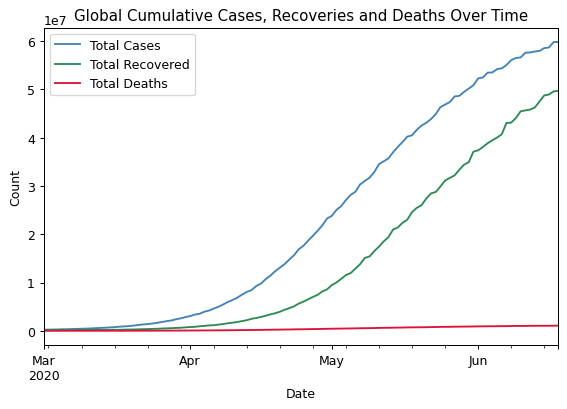

In [14]:
global_daily = df.groupby("date")[["total_cases", "total_deaths", "total_recovered"]].sum()

fig, ax = plt.subplots()
global_daily["total_cases"].plot(ax=ax, label="Total Cases", color="steelblue")
global_daily["total_recovered"].plot(ax=ax, label="Total Recovered", color="seagreen")
global_daily["total_deaths"].plot(ax=ax, label="Total Deaths", color="crimson")
ax.set_title("Global Cumulative Cases, Recoveries and Deaths Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Daily New Cases (Global)

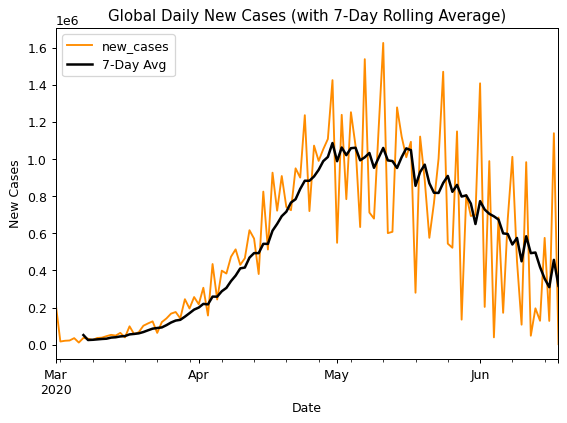

In [16]:
global_new = df.groupby("date")["new_cases"].sum()

fig, ax = plt.subplots()
global_new.plot(ax=ax, color="darkorange")
global_new.rolling(7).mean().plot(ax=ax, color="black", linewidth=2, label="7-Day Avg")
ax.set_title("Global Daily New Cases (with 7-Day Rolling Average)")
ax.set_xlabel("Date")
ax.set_ylabel("New Cases")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Country-Wise Case Trajectories

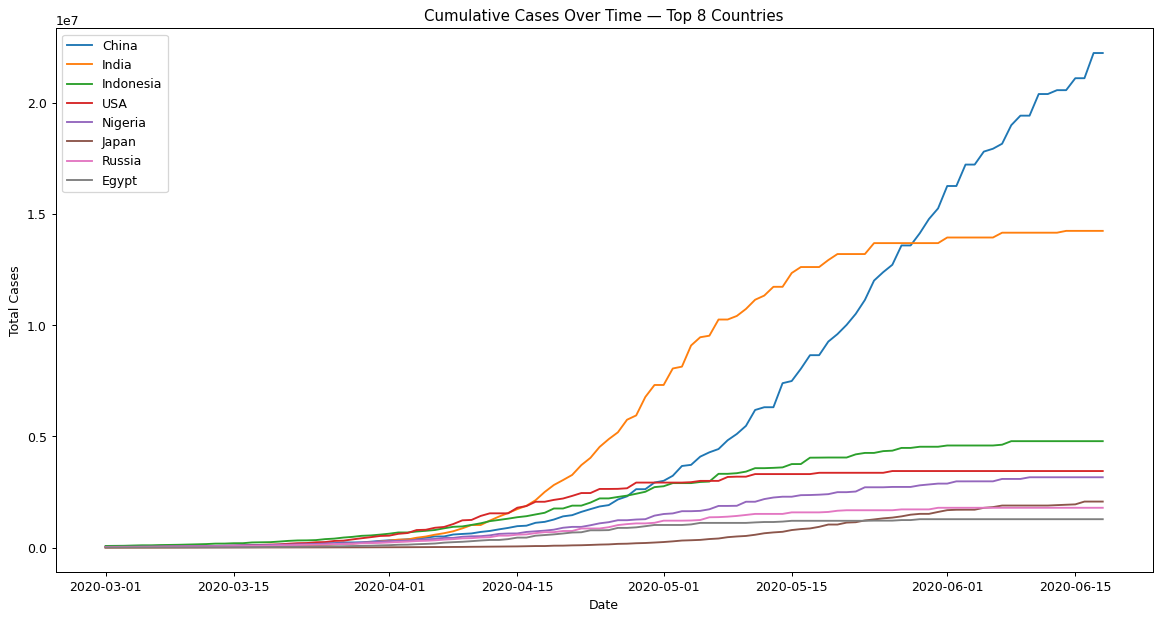

In [18]:
top_countries = df.groupby("country")["total_cases"].max().sort_values(ascending=False).head(8).index

fig, ax = plt.subplots(figsize=(13, 7))
for country in top_countries:
    subset = df[df["country"] == country]
    ax.plot(subset["date"], subset["total_cases"], label=country)
ax.set_title("Cumulative Cases Over Time — Top 8 Countries")
ax.set_xlabel("Date")
ax.set_ylabel("Total Cases")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Continent-Wise Trend

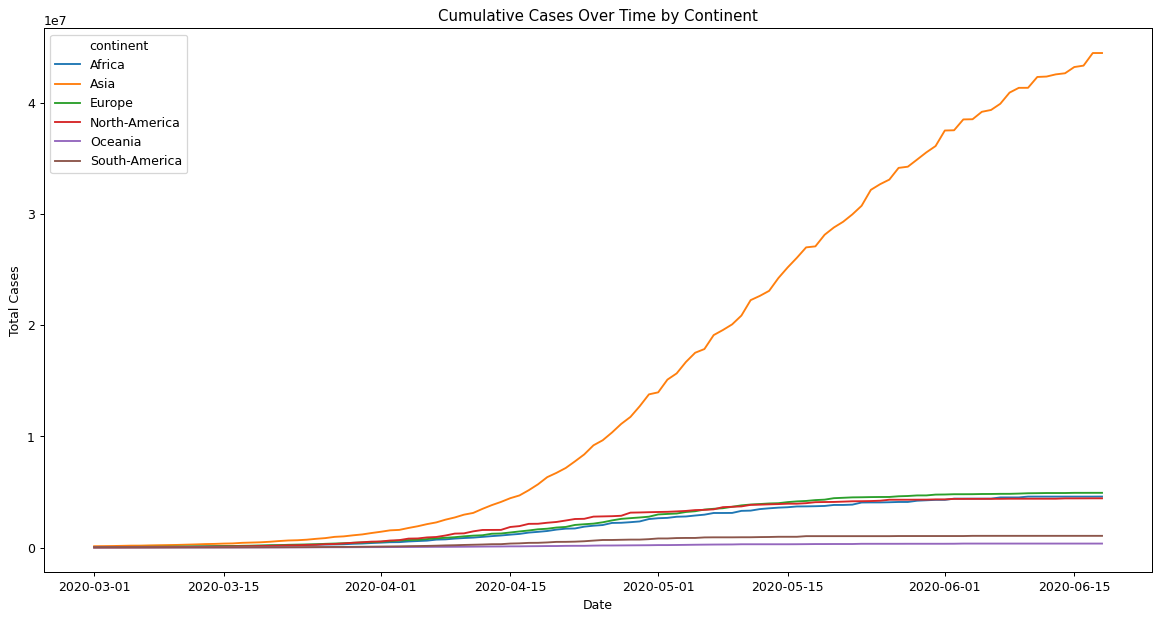

In [20]:
continent_daily = df.groupby(["date", "continent"])["total_cases"].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 7))
sns.lineplot(data=continent_daily, x="date", y="total_cases", hue="continent", ax=ax)
ax.set_title("Cumulative Cases Over Time by Continent")
ax.set_xlabel("Date")
ax.set_ylabel("Total Cases")
plt.tight_layout()
plt.show()

## 8. Latest Snapshot: Top 10 Countries by Total Cases

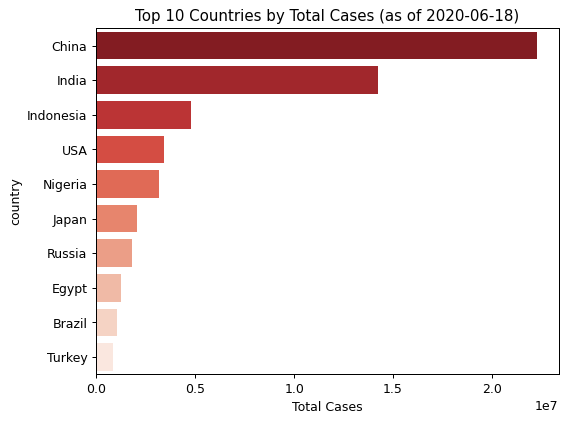

In [22]:
latest_date = df["date"].max()
latest = df[df["date"] == latest_date].sort_values("total_cases", ascending=False)

top10_latest = latest.head(10)
fig, ax = plt.subplots()
sns.barplot(data=top10_latest, x="total_cases", y="country", hue="country", palette="Reds_r", legend=False, ax=ax)
ax.set_title(f"Top 10 Countries by Total Cases (as of {latest_date.date()})")
ax.set_xlabel("Total Cases")
plt.tight_layout()
plt.show()

## 9. Death Rate and Recovery Rate (Latest Snapshot)

In [24]:
latest = latest.copy()
latest["death_rate_%"] = (latest["total_deaths"] / latest["total_cases"] * 100).round(2)
latest["recovery_rate_%"] = (latest["total_recovered"] / latest["total_cases"] * 100).round(2)

latest[["country", "total_cases", "death_rate_%", "recovery_rate_%"]].sort_values("death_rate_%", ascending=False)

,country,total_cases,death_rate_%,recovery_rate_%
109,Australia,357383,3.59,87.35
1759,South-Africa,146773,3.45,86.99
989,Indonesia,4787049,3.02,87.53
2199,USA,3442618,2.85,94.11
1979,Turkey,844798,2.74,88.82
2089,UK,618656,2.46,89.43
1319,Mexico,460362,2.34,88.02
1099,Italy,462473,2.27,91.53
1649,S-Korea,253937,2.25,74.09
1429,Nigeria,3162266,2.10,83.88


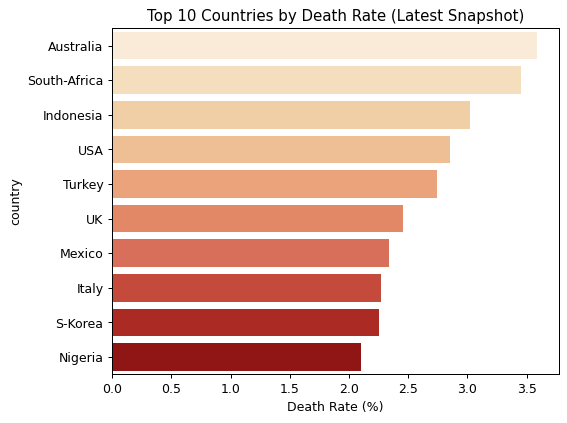

In [25]:
fig, ax = plt.subplots()
top_death_rate = latest.sort_values("death_rate_%", ascending=False).head(10)
sns.barplot(data=top_death_rate, x="death_rate_%", y="country", hue="country", palette="OrRd", legend=False, ax=ax)
ax.set_title("Top 10 Countries by Death Rate (Latest Snapshot)")
ax.set_xlabel("Death Rate (%)")
plt.tight_layout()
plt.show()

## 10. Cases per Million Population

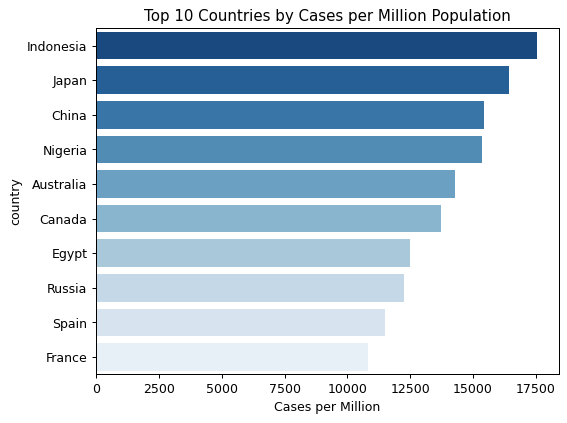

In [27]:
latest["cases_per_million"] = (latest["total_cases"] / latest["population"] * 1_000_000).round(0)

top_per_capita = latest.sort_values("cases_per_million", ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=top_per_capita, x="cases_per_million", y="country", hue="country", palette="Blues_r", legend=False, ax=ax)
ax.set_title("Top 10 Countries by Cases per Million Population")
ax.set_xlabel("Cases per Million")
plt.tight_layout()
plt.show()

## 11. Testing vs Cases

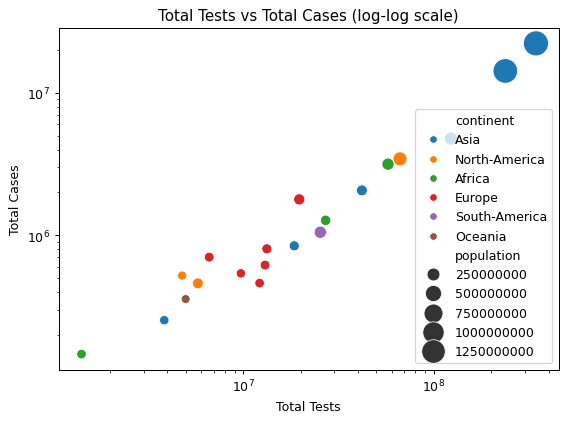

In [29]:
fig, ax = plt.subplots()
sns.scatterplot(data=latest, x="total_tests", y="total_cases", hue="continent", size="population",
                 sizes=(50, 400), ax=ax)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Total Tests vs Total Cases (log-log scale)")
ax.set_xlabel("Total Tests")
ax.set_ylabel("Total Cases")
plt.tight_layout()
plt.show()

## 12. Correlation Heatmap

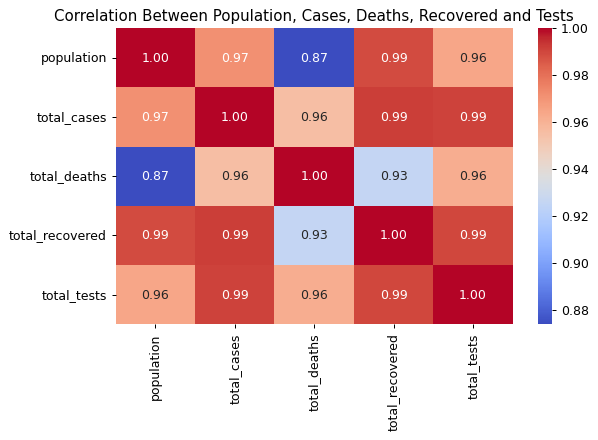

In [31]:
numeric_cols = ["population", "total_cases", "total_deaths", "total_recovered", "total_tests"]
corr = latest[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Between Population, Cases, Deaths, Recovered and Tests")
plt.tight_layout()
plt.show()

## 13. Key Insights

- The global curve shows a **clear S-shaped (logistic) growth pattern** typical of early pandemic waves — slow start, rapid acceleration, then a plateau.
- **7-day rolling average of new cases** smooths out day-to-day reporting noise and makes the underlying wave pattern much clearer than the raw daily numbers.
- **Country trajectories differ substantially** — some countries show a steep, early peak while others show a slower, later climb, reflecting differences in timing of outbreaks and interventions.
- **Death rate varies widely by country**, which likely reflects differences in healthcare capacity, testing coverage, and population demographics rather than the virus alone.
- **Cases per million** gives a very different ranking than raw case counts — smaller, densely affected countries can rank higher than large countries with more total cases.
- **Total tests and total cases are strongly correlated**, reinforcing that reported case counts are heavily influenced by how much testing a country conducts.
